In [2]:
from hossam import *

from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
import datetime as dt
from pandas import to_datetime, DataFrame, date_range, concat
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from sklearn.metrics import mean_absolute_error, mean_squared_error
import holidays

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid

from tqdm.auto import tqdm

import yfinance as yf

In [5]:
today = dt.datetime.now()
start = today - dt.timedelta(365 * 1)
start_day = start.strftime("%Y-%m-%d")
start_day

'2025-02-25'

In [6]:
origin = yf.download("005930.KS", start=start_day)
print("수입된 데이터 크기: ", len(origin))
origin.tail()

[*********************100%***********************]  1 of 1 completed

수입된 데이터 크기:  243


Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2026-02-19,190000.000,190900.000,187100.000,188000.000,27049388
2026-02-20,190100.000,190300.000,188600.000,190000.000,24213880
2026-02-23,193000.000,197600.000,190500.000,194400.000,26364684
2026-02-24,200000.000,200000.000,192000.000,193000.000,28060617
2026-02-25,203500.000,205000.000,201000.000,202500.000,12109338


In [7]:
df = origin.copy()
df.columns = df.columns.get_level_values(0)
df.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-02-19,190000.000,190900.000,187100.000,188000.000,27049388
2026-02-20,190100.000,190300.000,188600.000,190000.000,24213880
2026-02-23,193000.000,197600.000,190500.000,194400.000,26364684
2026-02-24,200000.000,200000.000,192000.000,193000.000,28060617
2026-02-25,203500.000,205000.000,201000.000,202500.000,12109338


In [8]:
max_y = df["Close"].max()
min_y = df["Close"].min()
max_y, min_y

(203500.0, 52189.21484375)

In [9]:
minmax = df.query("Close ==@max_y | Close == @min_y")
minmax

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-04-09,52189.215,53469.328,52090.745,52484.625,20576960
2026-02-25,203500.000,205000.000,201000.000,202500.000,12109338


In [10]:
min_date = minmax.index[0]
max_date = minmax.index[1]
min_date, max_date

(Timestamp('2025-04-09 00:00:00'), Timestamp('2026-02-25 00:00:00'))

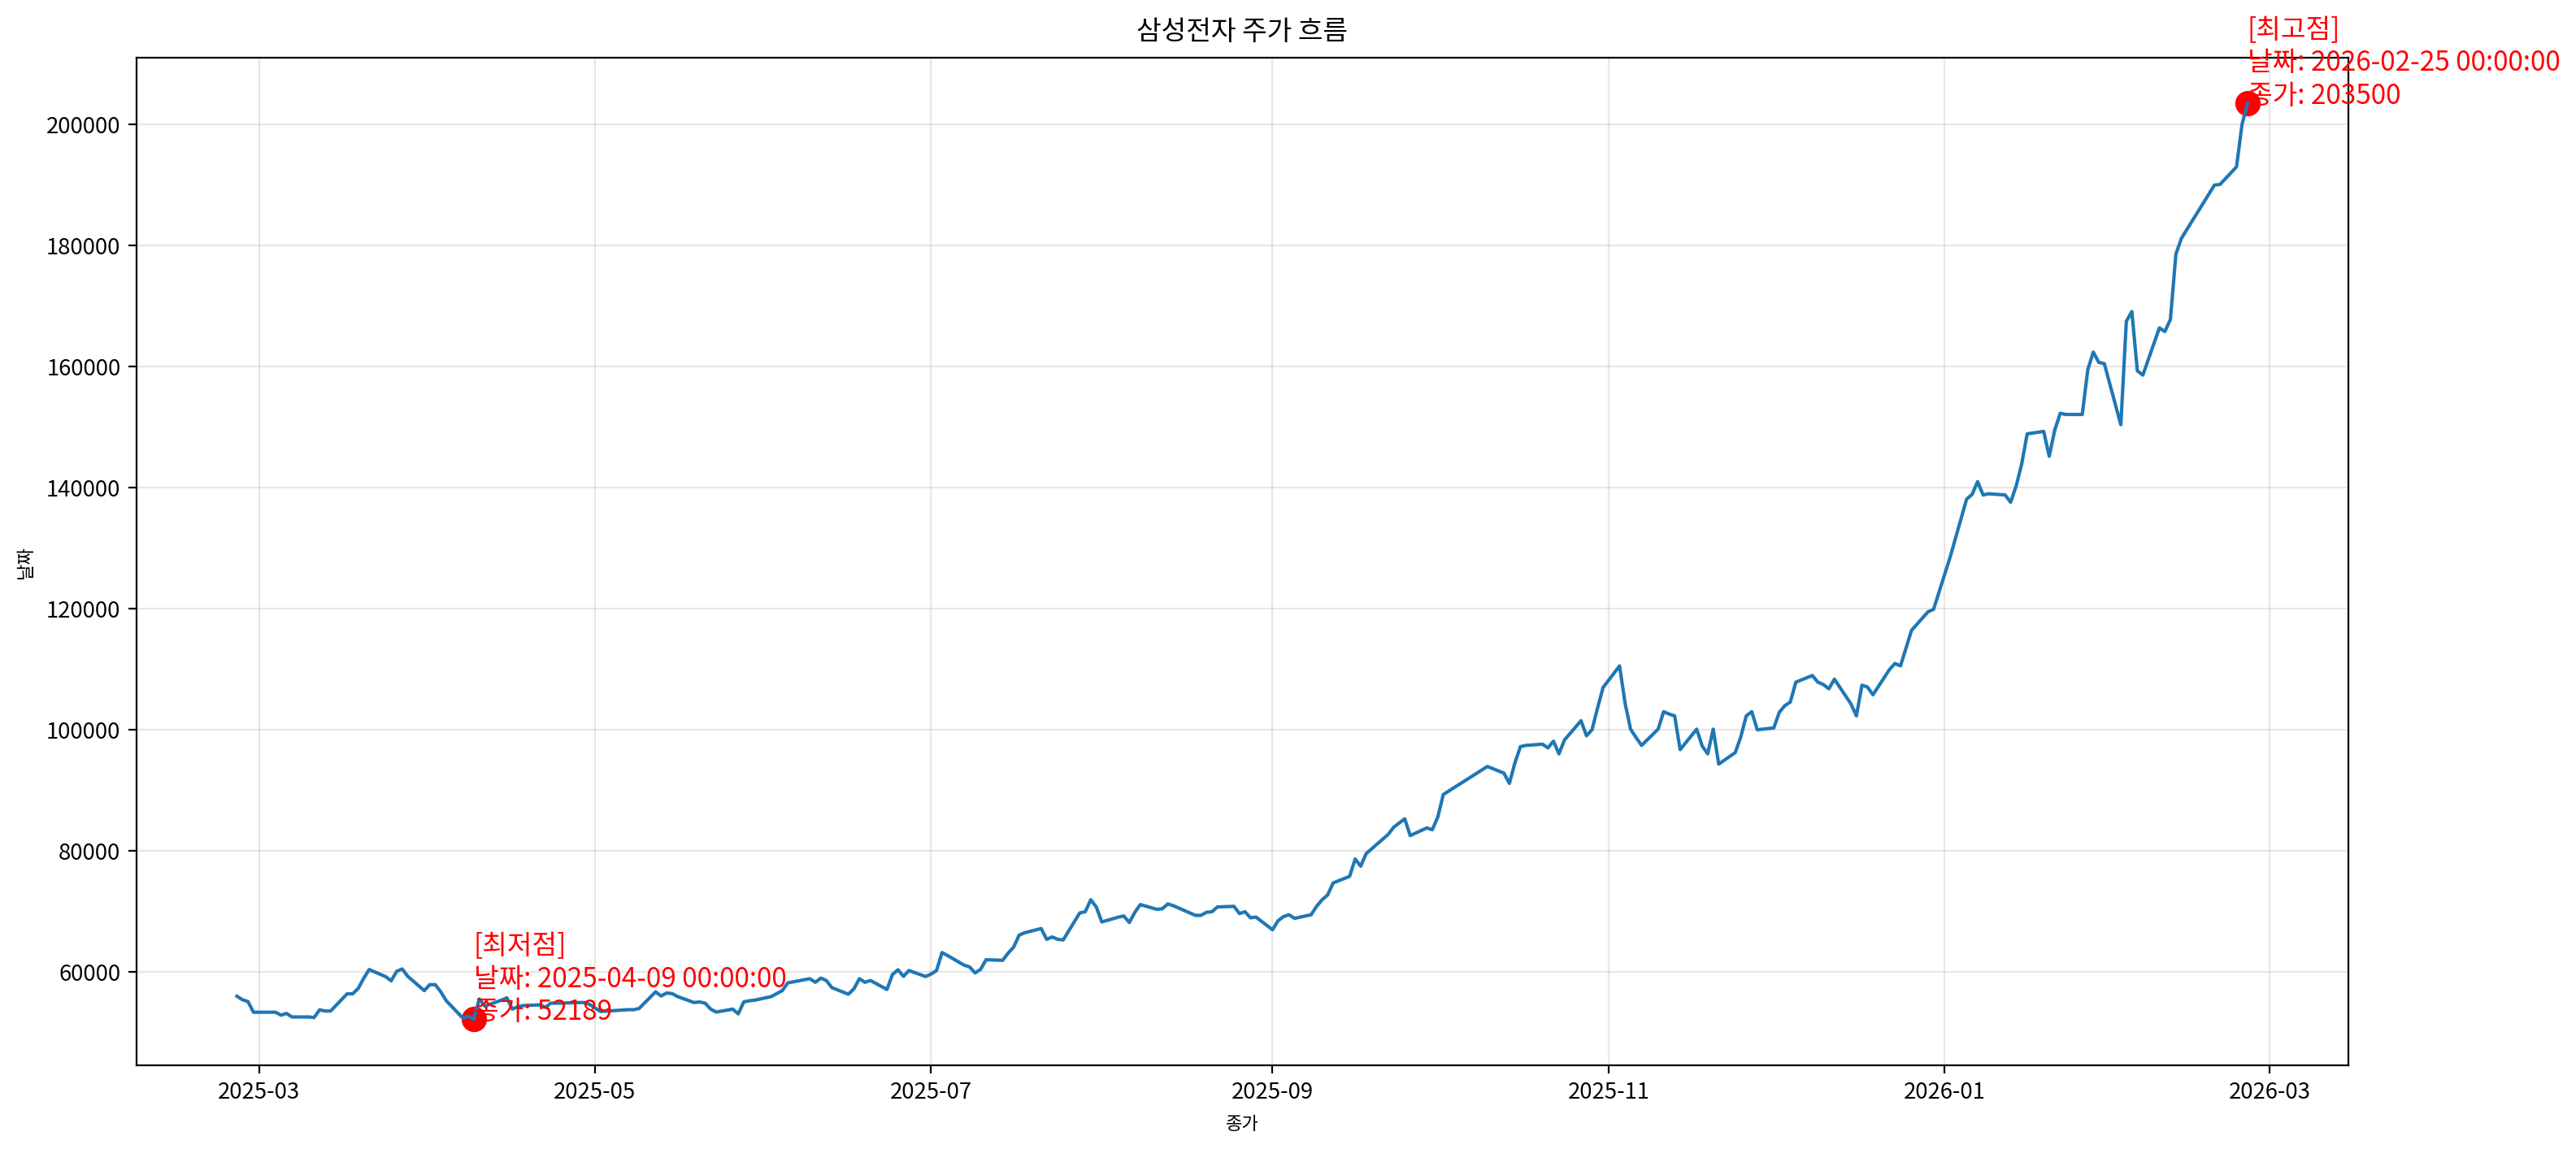

In [11]:
figsize = (1600 / 100, 720 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기 -> seaborn 사용
sb.lineplot(data=df, x=df.index, y="Close")
sb.scatterplot(
    data=minmax, x=minmax.index, y="Close", color="red", s=150, markers="o", ax=ax
)
ax.text(
    min_date,
    min_y,
    "[최저점]\n날짜: %s\n종가: %d" % (min_date, min_y),
    fontsize=12,
    color="red",
)
ax.text(
    max_date,
    max_y,
    "[최고점]\n날짜: %s\n종가: %d" % (max_date, max_y),
    fontsize=12,
    color="red",
)

# 3) 그래프 꾸미기
ax.set_title("삼성전자 주가 흐름", fontsize=12, pad=8)
ax.set_xlabel("종가", fontsize=8, labelpad=5)
ax.set_ylabel("날짜", fontsize=8, labelpad=5)
ax.grid(True, alpha=0.3)
# ax.set_xlim([, ])  # x축 범위
# ax.set_ylim([, ])  # y축 범위

plt.tight_layout()
plt.show()
plt.close()

In [12]:
df1 = df[["Close"]].copy()
df1.reset_index(inplace=True)
df1.head()

Price,Date,Close
0,2025-02-25,55992.297
1,2025-02-26,55404.969
2,2025-02-27,55111.297
3,2025-02-28,53349.305
4,2025-03-04,53349.305


In [13]:
df2 = df1.copy()
df2.rename(columns={"Date": "ds", "Close": "y"}, inplace=True)
df2["ds"] = to_datetime(df2["ds"])
df2.head()

Price,ds,y
0,2025-02-25,55992.297
1,2025-02-26,55404.969
2,2025-02-27,55111.297
3,2025-02-28,53349.305
4,2025-03-04,53349.305


In [14]:
# 분할 비율
split_ratio = 0.8

# 분할 인덱스
split_idx = int(len(df2) * split_ratio)

# 훈련 / 검증 데이터
train = df2.iloc[:split_idx]
test = df2.iloc[split_idx:]

print("Train 기간:", train["ds"].min(), "~", train["ds"].max())
print("Valid 기간:", test["ds"].min(), "~", test["ds"].max())

Train 기간: 2025-02-25 00:00:00 ~ 2025-12-10 00:00:00
Valid 기간: 2025-12-11 00:00:00 ~ 2026-02-25 00:00:00


In [15]:
start_date = train["ds"].min()
end_date = test["ds"].max()

# 주말 데이터
sat = date_range(start=start_date, end=end_date, freq="W-SAT")
sun = date_range(start=start_date, end=end_date, freq="W-SUN")

weekend = sat.union(sun)
df_weekend = DataFrame(
    {
        "holiday": "weekend",
        "ds": weekend.sort_values(),
        "lower_window": 0,
        "upper window": 0,
    }
)
df_weekend.head()

,holiday,ds,lower_window,upper window
0,weekend,2025-03-01,0,0
1,weekend,2025-03-02,0,0
2,weekend,2025-03-08,0,0
3,weekend,2025-03-09,0,0
4,weekend,2025-03-15,0,0


In [16]:
years = list(range(to_datetime(start_date).year, to_datetime(end_date).year + 1))
kr = holidays.KR(years=years)
hd_dict = {"holiday": [], "ds": [], "lower_window": [], "upper_window": []}
for date, name in kr.items():
    hd_dict["holiday"].append(name)
    hd_dict["ds"].append(date)
    hd_dict["lower_window"].append(0)
    hd_dict["upper_window"].append(0)
df_holidays = DataFrame(hd_dict)
df_holidays["ds"] = to_datetime(df_holidays["ds"])
df_holidays.sort_values("ds", inplace=True)
df_holidays.head()

,holiday,ds,lower_window,upper_window
0,New Year's Day,2025-01-01,0,0
17,Temporary Public Holiday,2025-01-27,0,0
2,The day preceding Korean New Year,2025-01-28,0,0
1,Korean New Year,2025-01-29,0,0
3,The second day of Korean New Year,2025-01-30,0,0


In [17]:
holydays_final = concat([df_weekend, df_holidays], ignore_index=True)

holydays_final.sort_values("ds", inplace=True)

holydays_final.reset_index(drop=True, inplace=True)
holydays_final.head(10)

,holiday,ds,lower_window,upper window,upper_window
0,New Year's Day,2025-01-01,0,NaN,0.000
1,Temporary Public Holiday,2025-01-27,0,NaN,0.000
2,The day preceding Korean New Year,2025-01-28,0,NaN,0.000
3,Korean New Year,2025-01-29,0,NaN,0.000
4,The second day of Korean New Year,2025-01-30,0,NaN,0.000
5,Independence Movement Day,2025-03-01,0,NaN,0.000
6,weekend,2025-03-01,0,0.000,NaN
7,weekend,2025-03-02,0,0.000,NaN
8,Alternative holiday for Independence Movement Day,2025-03-03,0,NaN,0.000
9,weekend,2025-03-08,0,0.000,NaN


In [18]:
mask = (holydays_final["ds"] >= start_date) & (holydays_final["ds"] <= end_date)
holydays_final = holydays_final.loc[mask].reset_index(drop=True)
holydays_final.head()

,holiday,ds,lower_window,upper window,upper_window
0,Independence Movement Day,2025-03-01,0,NaN,0.000
1,weekend,2025-03-01,0,0.000,NaN
2,weekend,2025-03-02,0,0.000,NaN
3,Alternative holiday for Independence Movement Day,2025-03-03,0,NaN,0.000
4,weekend,2025-03-08,0,0.000,NaN


In [19]:
params = ParameterGrid(
    {
        "growth": ["linear"],
        "changepoint_prior_scale": [0.01, 0.1, 1.0],
        "seasonality_mode": ["additive", "multiplicative"],
        "yearly_seasonality": [True],
        "weekly_seasonality": [True],
        "daily_seasonality": [False],
        "holidays": [holydays_final],
    }
)

print("Total Possible Models", len(params))

Total Possible Models 6


In [20]:
%%time

import logging
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

result = []

with tqdm(total=len(params)) as pbar:
    for i, p in enumerate(params):

        pbar.set_description(f"Model {i+1}/{len(params)}")

        m = Prophet(**p)
        m.fit(train)

        future = m.make_future_dataframe(periods=len(test), freq='D')
        forecast = m.predict(future)

        pred = forecast[['ds', 'yhat']][-len(test):]
        score = np.sqrt(mean_squared_error(test['y'].values, pred['yhat'].values))

        result.append({
            "score": score,
            "model": m,
            "params": p,
        })

        pbar.update(1)

# result 배열에서 score가 가장 좋은 모델을 찾는다.
# RMSE가 가장 낮은 모델이 가장 좋은 모델이므로, score가 가장 작은 모델을 찾는다.
best_index = min(result, key=lambda x: x['score'])
best_model = best_index['model']
best_params = best_index['params']
best_score = best_index['score']

print("Best Score (RMSE):", best_score)
print("Best Parameters:", best_params)

  0%|          | 0/6 [00:00<?, ?it/s]

11:31:16 - cmdstanpy - INFO - Chain [1] start processing
11:31:16 - cmdstanpy - INFO - Chain [1] done processing
11:31:16 - cmdstanpy - INFO - Chain [1] start processing
11:31:16 - cmdstanpy - INFO - Chain [1] done processing
11:31:16 - cmdstanpy - INFO - Chain [1] start processing
11:31:16 - cmdstanpy - INFO - Chain [1] done processing
11:31:17 - cmdstanpy - INFO - Chain [1] start processing
11:31:17 - cmdstanpy - INFO - Chain [1] done processing
11:31:17 - cmdstanpy - INFO - Chain [1] start processing
11:31:17 - cmdstanpy - INFO - Chain [1] done processing
11:31:17 - cmdstanpy - INFO - Chain [1] start processing
11:31:17 - cmdstanpy - INFO - Chain [1] done processing


Best Score (RMSE): 47734.0075517679
Best Parameters: {'changepoint_prior_scale': 0.01, 'daily_seasonality': False, 'growth': 'linear', 'holidays':                                                holiday         ds  \
0                            Independence Movement Day 2025-03-01   
1                                              weekend 2025-03-01   
2                                              weekend 2025-03-02   
3    Alternative holiday for Independence Movement Day 2025-03-03   
4                                              weekend 2025-03-08   
..                                                 ...        ...   
117                  The day preceding Korean New Year 2026-02-16   
118                                    Korean New Year 2026-02-17   
119                  The second day of Korean New Year 2026-02-18   
120                                            weekend 2026-02-21   
121                                            weekend 2026-02-22   

     lower_window  upper

In [21]:
# 실제 예측 데이터보다 7단계 더 미래까지 예측해보자. (1주일)
future = best_model.make_future_dataframe(periods=len(test) + 7, freq="D")
forecast = best_model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Alternative holiday for Buddha's Birthday; Alternative holiday for Children's Day,Alternative holiday for Buddha's Birthday; Alternative holiday for Children's Day_lower,Alternative holiday for Buddha's Birthday; Alternative holiday for Children's Day_upper,Alternative holiday for Chuseok,Alternative holiday for Chuseok_lower,Alternative holiday for Chuseok_upper,Alternative holiday for Independence Movement Day,Alternative holiday for Independence Movement Day_lower,Alternative holiday for Independence Movement Day_upper,Buddha's Birthday; Children's Day,Buddha's Birthday; Children's Day_lower,Buddha's Birthday; Children's Day_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Chuseok,Chuseok_lower,Chuseok_upper,Hangul Day,Hangul Day_lower,Hangul Day_upper,Independence Movement Day,Independence Movement Day_lower,Independence Movement Day_upper,Korean New Year,Korean New Year_lower,Korean New Year_upper,Liberation Day,Liberation Day_lower,Liberation Day_upper,Memorial Day,Memorial Day_lower,Memorial Day_upper,National Foundation Day,National Foundation Day_lower,National Foundation Day_upper,New Year's Day,New Year's Day_lower,New Year's Day_upper,Presidential Election Day,Presidential Election Day_lower,Presidential Election Day_upper,The day preceding Chuseok,The day preceding Chuseok_lower,The day preceding Chuseok_upper,The day preceding Korean New Year,The day preceding Korean New Year_lower,The day preceding Korean New Year_upper,The second day of Chuseok,The second day of Chuseok_lower,The second day of Chuseok_upper,The second day of Korean New Year,The second day of Korean New Year_lower,The second day of Korean New Year_upper,holidays,holidays_lower,holidays_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,weekend,weekend_lower,weekend_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2025-02-25,49594.910,52871.389,56904.026,49594.910,49594.910,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.107,0.107,0.107,0.000,0.000,0.000,-0.024,-0.024,-0.024,0.131,0.131,0.131,0.000,0.000,0.000,54911.921
1,2025-02-26,49766.430,52682.537,56689.763,49766.430,49766.430,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.098,0.098,0.098,0.000,0.000,0.000,-0.021,-0.021,-0.021,0.119,0.119,0.119,0.000,0.000,0.000,54647.495
2,2025-02-27,49937.951,52497.450,56799.976,49937.951,49937.951,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.094,0.094,0.094,0.000,0.000,0.000,-0.014,-0.014,-0.014,0.108,0.108,0.108,0.000,0.000,0.000,54627.863
3,2025-02-28,50109.471,51856.209,55918.308,50109.471,50109.471,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.076,0.076,0.076,0.000,0.000,0.000,-0.022,-0.022,-0.022,0.098,

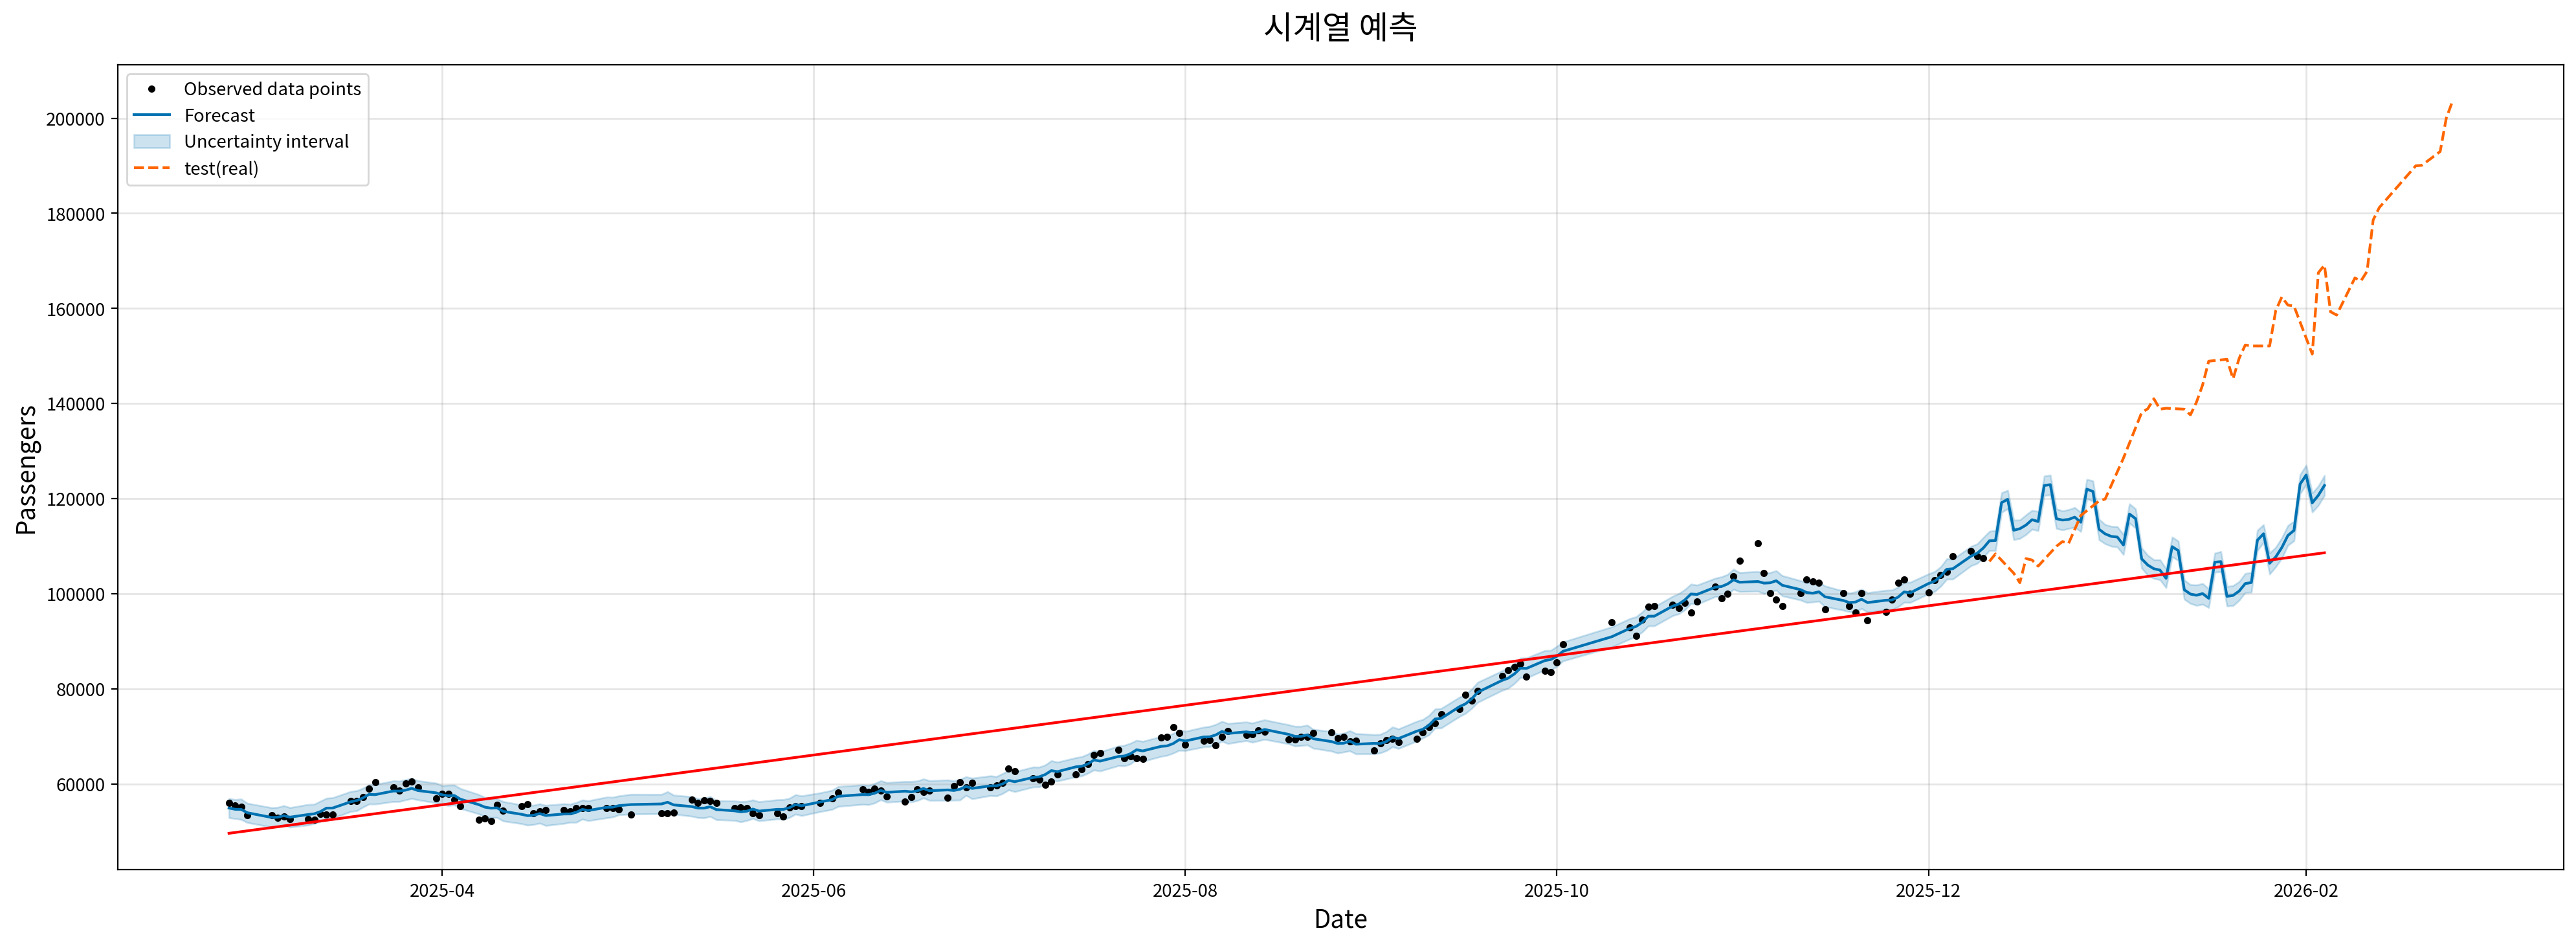

In [22]:
fig = best_model.plot(
    forecast, figsize=(20, 7), xlabel="Date", ylabel="Passengers", uncertainty=True
)
ax = fig.gca()
add_changepoints_to_plot(ax, best_model, forecast)
ax.set_title("시계열 예측")

# 실제 검증 데이터는 직접 추가한다.
sb.lineplot(
    data=test, x="ds", y="y", ax=ax, color="#ff6600", linestyle="--", label="test(real)"
)

plt.show()
plt.close()

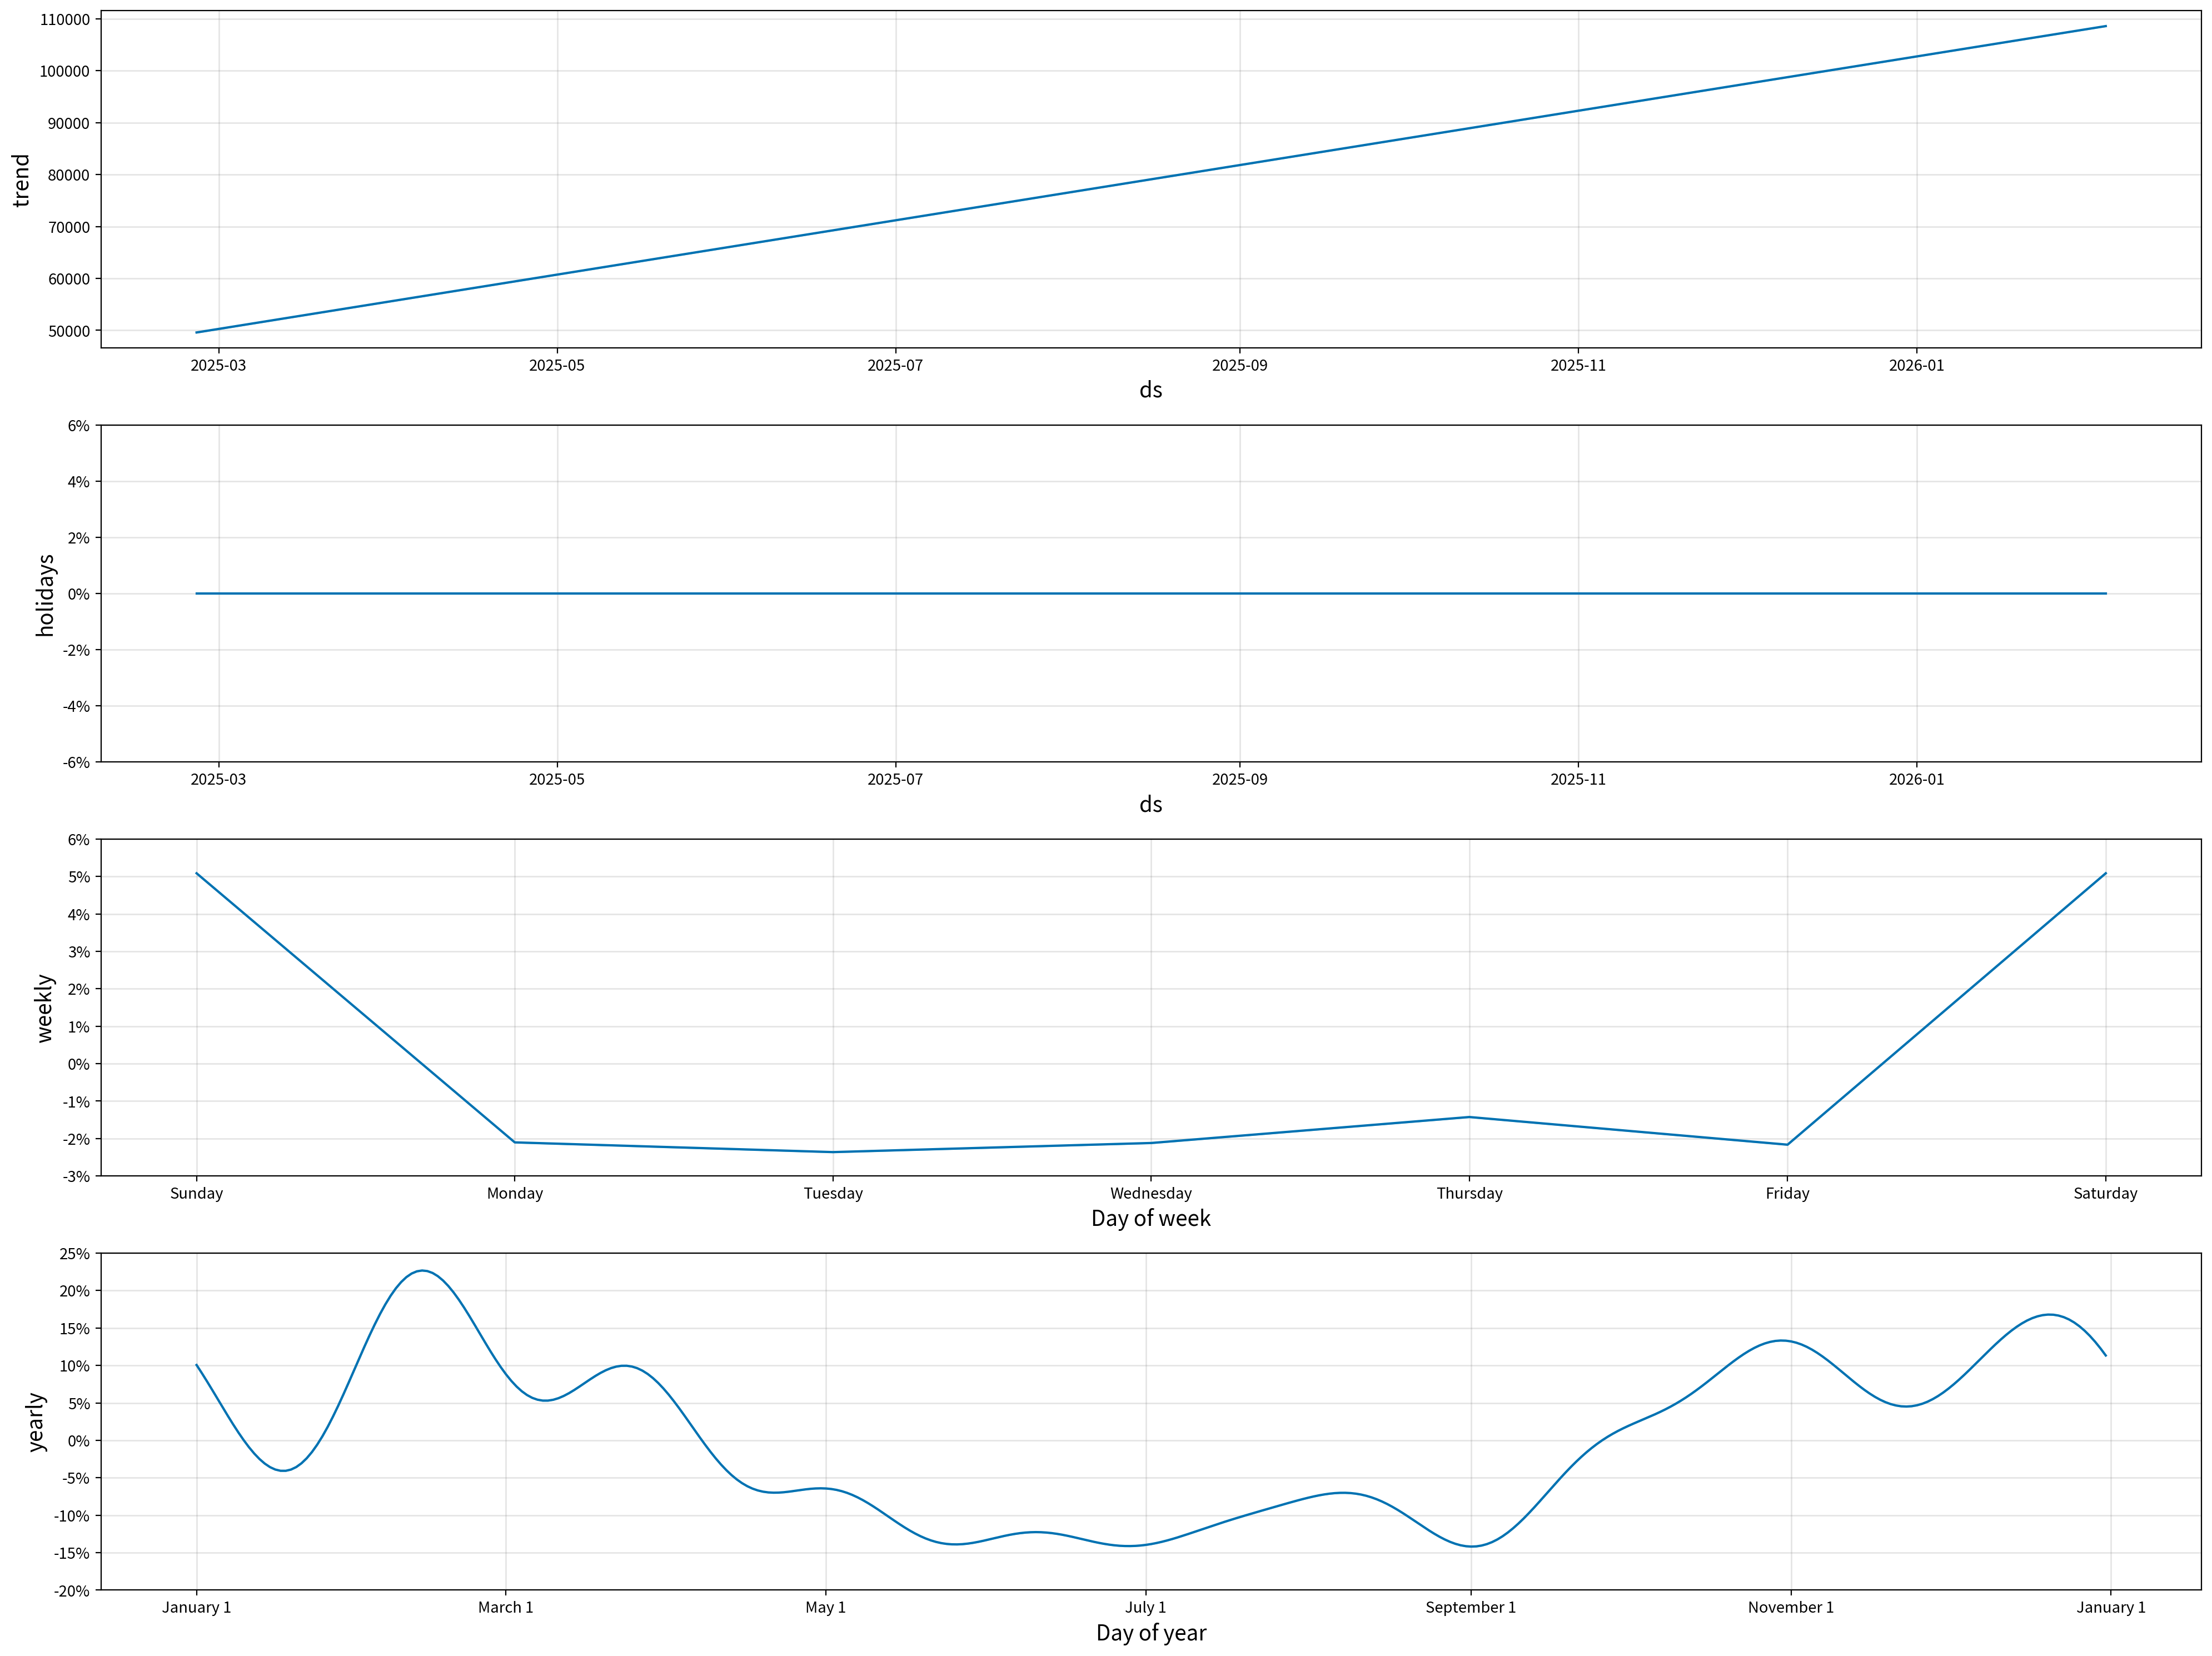

In [23]:
fig = best_model.plot_components(forecast, figsize=(20, 15))
ax = fig.gca()
plt.show()
plt.close()